# Parameter Estimation, Metrics & Regularization
*Data 200 · Applied Statistical Analysis · Instructor: Aayush Regmi*

---

In the [Linear Regression notebook](LinearRegression.md) we used the
**closed-form OLS solution**
$\hat{\boldsymbol\beta} = (X^\top X)^{-1} X^\top y$ to fit models. That
formula is elegant, but it's not the only game in town — and it has real
limitations when datasets get large or predictors get nasty.

This notebook rounds out the linear-regression toolkit with **four more
topics** every applied statistician needs:

1. **Gradient Descent** — an iterative alternative to OLS that scales to
   huge datasets and works with almost any loss function.
2. **Maximum Likelihood Estimation (MLE)** — the *probabilistic* view of
   parameter estimation that unifies linear regression with logistic
   regression, Poisson regression, and the rest of the GLM family.
3. **Regression Metrics** — how we actually measure whether a fitted
   model is any good: MAE, MSE, RMSE, $R^2$, Adjusted $R^2$, MAPE.
4. **Regularization** — Ridge, Lasso, and Elastic Net — with
   visualizations that show *why* and *how* they tame overfitting.

> Re-run each cell yourself. The plots are designed to be poked at —
> change a learning rate, a regularization strength, or a polynomial
> degree and watch the whole story shift.

## Learning Objectives

By the end of this notebook you should be able to:

1. Explain **three concrete limitations** of the closed-form OLS solution
   and describe how Gradient Descent addresses each one.
2. Implement **vanilla batch Gradient Descent** for linear regression
   from scratch, and describe how Stochastic and Mini-batch variants
   differ.
3. Diagnose a failing optimizer from its **loss curve** — distinguish
   "learning rate too small", "learning rate too large", and "converged".
4. Write down the **log-likelihood** of a linear regression model under
   Gaussian noise and show that **MLE ≡ OLS** in that setting.
5. Compute **MAE, MSE, RMSE, $R^2$, Adj-$R^2$, MAPE** on a real dataset
   and pick the right metric for a given business question.
6. Explain what **Ridge** and **Lasso** do to the OLS objective,
   visualize the **regularization path**, and describe the geometric
   reason Lasso can zero coefficients out while Ridge cannot.

## 1. The Optimization View of Regression

Everything we do in this notebook sits inside one sentence:

> **Fitting a model = solving an optimization problem.**

For linear regression that problem is

$$\hat{\boldsymbol\beta} \;=\; \arg\min_{\boldsymbol\beta}\; L(\boldsymbol\beta)
\quad\text{with}\quad L(\boldsymbol\beta) \;=\; \sum_{i=1}^n \bigl(y_i - \mathbf{x}_i^\top \boldsymbol\beta\bigr)^2.$$

There are **three** standard ways to solve it:

| Method | How it works | When to use |
|---|---|---|
| **Closed-form (OLS)** | Set the gradient to zero and solve algebraically: $\hat{\boldsymbol\beta} = (X^\top X)^{-1} X^\top y$ | Small to medium datasets, well-conditioned $X$ |
| **Iterative (Gradient Descent)** | Walk downhill on $L$ one small step at a time | Huge or streaming data, custom losses, non-invertible $X^\top X$ |
| **Probabilistic (MLE)** | Write $y$ as coming from a distribution and maximize its likelihood | GLMs, logistic regression, anything non-Gaussian |

All three give the **same answer** for vanilla linear regression with
Gaussian noise — but they open very different doors.

## 2. Setup — Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, ElasticNet,
    RidgeCV, LassoCV,
)
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    mean_absolute_percentage_error,
)
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split

import statsmodels.api as sm
from scipy import optimize, stats

sns.set_theme(style="whitegrid")
rng = np.random.default_rng(42)

## 3. Limitations of the Closed-Form OLS Solution

The formula $\hat{\boldsymbol\beta} = (X^\top X)^{-1} X^\top y$ is beautiful
but hides three practical problems:

### 3.1 Cost — matrix inversion is $O(p^3)$

Computing $(X^\top X)^{-1}$ costs on the order of $p^3$ floating-point
operations, where $p$ is the number of predictors. For $p = 10$ that's
nothing; for $p = 10{,}000$ it's ten **trillion** operations — and you
need $p^2 \approx 10^8$ floats just to store the matrix.

### 3.2 Memory and streaming — it all has to fit

OLS wants *all the data at once* so it can build $X^\top X$ and
$X^\top y$. If your data arrives one row at a time (clickstreams, sensor
feeds, recommender logs) you can't use it directly.

### 3.3 Fragility — $X^\top X$ can be singular

If two predictors are (nearly) linear combinations of each other,
$X^\top X$ becomes singular or nearly so, and the inverse either doesn't
exist or explodes numerically. Let's reproduce this.

In [2]:
# Build two nearly-identical columns
n = 200
x1 = rng.normal(size=n)
x2 = x1 + rng.normal(scale=1e-6, size=n)          # nearly a copy
y  = 3 * x1 - 2 * x2 + rng.normal(scale=0.5, size=n)

X_bad = np.column_stack([np.ones(n), x1, x2])

try:
    beta_ols = np.linalg.inv(X_bad.T @ X_bad) @ X_bad.T @ y
    print("OLS succeeded — coefficients:", beta_ols.round(2))
except np.linalg.LinAlgError as e:
    print("OLS failed:", e)

cond = np.linalg.cond(X_bad.T @ X_bad)
print(f"\nCondition number of X\u1d40X : {cond:.2e}")
print("(anything above ~1e8 means the inverse is numerically unreliable)")

OLS succeeded — coefficients: [-4.000000e-02 -1.540712e+04  1.540809e+04]

Condition number of XᵀX : 3.02e+12
(anything above ~1e8 means the inverse is numerically unreliable)


The condition number is astronomical — the "solution" OLS returns for
the two almost-identical columns is essentially random noise. Gradient
Descent, as we'll see in Section 4, *never computes this inverse* so it
is much more robust here.

## 4. Gradient Descent — The Workhorse of Modern ML

### 4.1 The core idea

Imagine you're standing on a hilly landscape $L(\boldsymbol\beta)$ in the
fog. You can't see the valley, but you can feel the **slope** under your
feet. A sensible strategy is:

1. Feel which way is **downhill** (compute the gradient).
2. Take a small step in that direction.
3. Repeat until the ground feels flat.

Formally, the **update rule** is

$$\boldsymbol\beta^{(t+1)} \;=\; \boldsymbol\beta^{(t)} \;-\; \eta\,\nabla L\!\left(\boldsymbol\beta^{(t)}\right)$$

where $\eta > 0$ is the **learning rate**. For the MSE loss

$$L(\boldsymbol\beta) \;=\; \frac{1}{n}\sum_{i=1}^n (y_i - \mathbf{x}_i^\top \boldsymbol\beta)^2$$

the gradient has a clean closed form:

$$\nabla L(\boldsymbol\beta) \;=\; \frac{2}{n}\, X^\top (X\boldsymbol\beta - y).$$

### 4.2 A one-minute warm-up

Before tackling regression, let's minimize $f(x) = (x - 3)^2$, which
obviously has a minimum at $x = 3$. The derivative is $f'(x) = 2(x - 3)$
so the update rule is $x \leftarrow x - \eta \cdot 2(x - 3)$.

Started at x = -2.000
Ended   at x = 3.0000  (target: 3.0000)


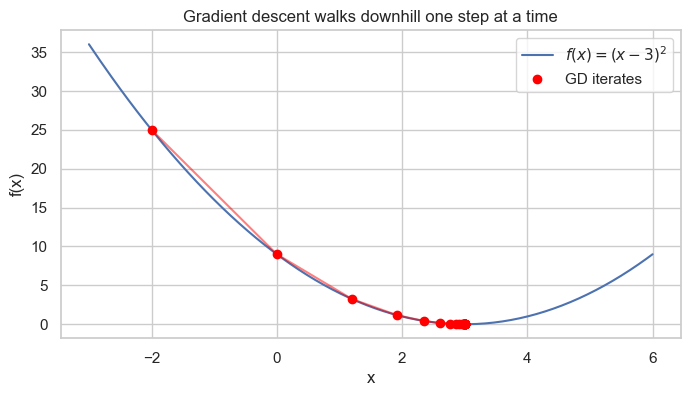

In [3]:
def minimize_1d(x0=0.0, lr=0.1, n_iter=30):
    xs = [x0]
    x = x0
    for _ in range(n_iter):
        grad = 2 * (x - 3)
        x = x - lr * grad
        xs.append(x)
    return np.array(xs)

traj = minimize_1d(x0=-2.0, lr=0.2, n_iter=25)
print(f"Started at x = {traj[0]:.3f}")
print(f"Ended   at x = {traj[-1]:.4f}  (target: 3.0000)")

xs = np.linspace(-3, 6, 200)
plt.figure(figsize=(8, 4))
plt.plot(xs, (xs - 3) ** 2, label=r"$f(x) = (x-3)^2$")
plt.scatter(traj, (traj - 3) ** 2, color='red', zorder=3,
            label="GD iterates")
plt.plot(traj, (traj - 3) ** 2, color='red', alpha=0.5)
plt.xlabel("x"); plt.ylabel("f(x)")
plt.title("Gradient descent walks downhill one step at a time")
plt.legend(); plt.show()

### 4.3 Gradient descent for linear regression

Now let's use GD to fit a linear regression. We'll generate data from the
model $y = 2 + 3x + \varepsilon$, then see if GD can recover the true
slope and intercept.

In [4]:
# Synthetic linear data
n = 200
x = rng.uniform(-2, 2, n)
y = 2 + 3 * x + rng.normal(scale=1.0, size=n)
X = np.column_stack([np.ones(n), x])          # [1, x] with intercept

def gradient_descent(X, y, lr=0.05, n_iter=200):
    n, p = X.shape
    beta = np.zeros(p)
    history = [beta.copy()]
    losses  = [np.mean((X @ beta - y) ** 2)]
    for _ in range(n_iter):
        grad = (2 / n) * X.T @ (X @ beta - y)
        beta = beta - lr * grad
        history.append(beta.copy())
        losses.append(np.mean((X @ beta - y) ** 2))
    return beta, np.array(history), np.array(losses)

beta_gd, path, losses = gradient_descent(X, y, lr=0.05, n_iter=200)
beta_ols = np.linalg.inv(X.T @ X) @ X.T @ y

print(f"True parameters        : [2.00, 3.00]")
print(f"OLS (closed form)      : {beta_ols.round(3).tolist()}")
print(f"Gradient Descent       : {beta_gd.round(3).tolist()}")

True parameters        : [2.00, 3.00]
OLS (closed form)      : [1.975, 2.999]
Gradient Descent       : [1.975, 2.999]


### 4.4 Visualizing the loss surface and the descent path

Because the model has only two parameters $(\beta_0, \beta_1)$, we can
plot the entire loss surface and overlay the sequence of GD iterates.

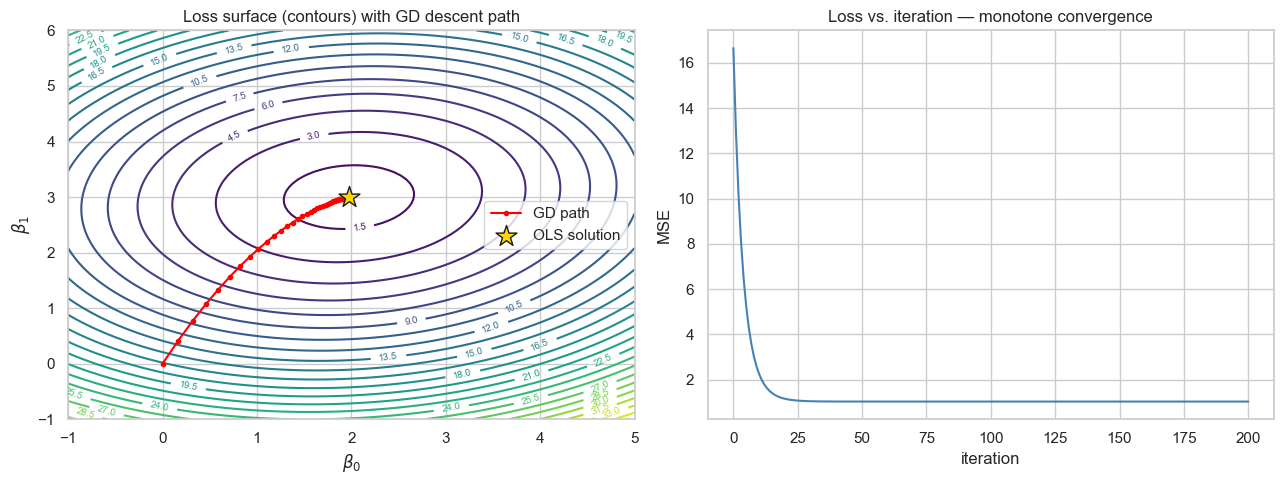

In [5]:
# Build a grid over (b0, b1) and evaluate the loss
b0_grid = np.linspace(-1, 5, 100)
b1_grid = np.linspace(-1, 6, 100)
B0, B1 = np.meshgrid(b0_grid, b1_grid)
L = np.zeros_like(B0)
for i in range(B0.shape[0]):
    for j in range(B0.shape[1]):
        beta = np.array([B0[i, j], B1[i, j]])
        L[i, j] = np.mean((X @ beta - y) ** 2)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# Contour plot with GD trajectory
cs = ax[0].contour(B0, B1, L, levels=25, cmap="viridis")
ax[0].clabel(cs, inline=True, fontsize=7)
ax[0].plot(path[:, 0], path[:, 1], "-o", color="red",
           markersize=3, label="GD path")
ax[0].scatter(*beta_ols, marker="*", color="gold",
              s=250, edgecolor="k", label="OLS solution", zorder=5)
ax[0].set(xlabel=r"$\beta_0$", ylabel=r"$\beta_1$",
          title="Loss surface (contours) with GD descent path")
ax[0].legend()

# Loss curve
ax[1].plot(losses, color="steelblue")
ax[1].set(xlabel="iteration", ylabel="MSE",
          title="Loss vs. iteration — monotone convergence")
plt.tight_layout()
plt.show()

### 4.5 The learning rate matters — a lot

Picking $\eta$ is the whole game. Too small and you'll take forever; too
large and the iterates **diverge** (bounce out of the bowl). Let's plot
the loss curve for four different learning rates on the same data.

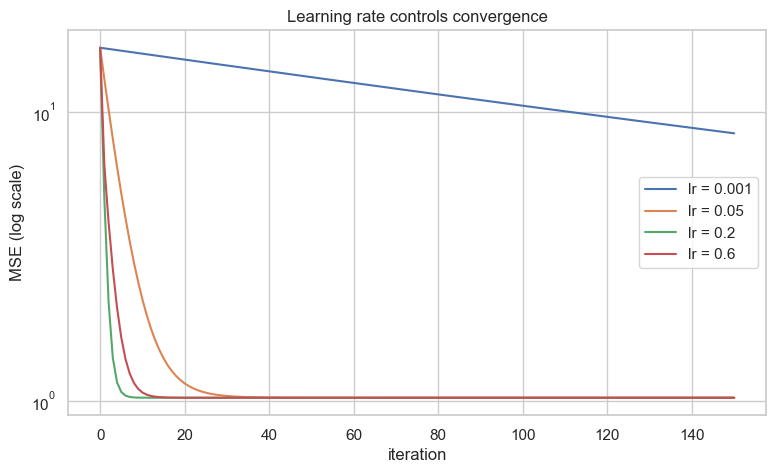

In [6]:
lrs = [0.001, 0.05, 0.2, 0.6]
plt.figure(figsize=(9, 5))
for lr in lrs:
    _, _, lc = gradient_descent(X, y, lr=lr, n_iter=150)
    label = f"lr = {lr}"
    plt.plot(lc, label=label)
plt.yscale("log")
plt.xlabel("iteration")
plt.ylabel("MSE (log scale)")
plt.title("Learning rate controls convergence")
plt.legend()
plt.show()

**Reading the plot**

- $\eta = 0.001$ — converges, but painfully slowly.
- $\eta = 0.05$  — the sweet spot: smooth, fast descent.
- $\eta = 0.2$   — still converges, now oscillating.
- $\eta = 0.6$   — **diverges**: the loss shoots up and never recovers.

**Rule of thumb:** start small, and if the loss curve is still smooth
after a few hundred iterations, try a larger $\eta$. If it spikes,
back off.

### 4.6 Batch, Stochastic, and Mini-batch GD

So far each step used **all $n$ samples** to compute the gradient — this
is **Batch GD**. For huge datasets that single step is expensive. Two
popular relaxations:

| Variant | Samples per step | Trade-off |
|---|---|---|
| **Batch GD** | all $n$ | Exact gradient, expensive per step, smooth convergence |
| **Stochastic GD (SGD)** | **1** random sample | Noisy but very cheap steps, can escape bad spots, needs smaller $\eta$ |
| **Mini-batch GD** | small batch (e.g. 32) | The modern default — good gradient estimate, cheap, plays nicely with GPUs |

The noise in SGD actually helps in deep learning (it acts as a regularizer
and helps escape saddle points). For convex problems like linear
regression it merely complicates convergence a bit.

SGD final coefficients: [1.801, 2.962]


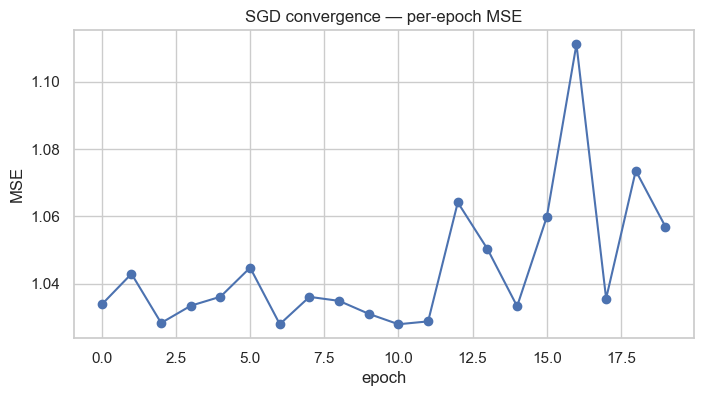

In [7]:
def sgd(X, y, lr=0.01, n_epochs=20):
    n, p = X.shape
    beta = np.zeros(p)
    losses = []
    for _ in range(n_epochs):
        for i in rng.permutation(n):
            xi = X[i]
            grad = 2 * xi * (xi @ beta - y[i])
            beta = beta - lr * grad
        losses.append(np.mean((X @ beta - y) ** 2))
    return beta, np.array(losses)

beta_sgd, loss_sgd = sgd(X, y, lr=0.01, n_epochs=20)
print(f"SGD final coefficients: {beta_sgd.round(3).tolist()}")

plt.figure(figsize=(8, 4))
plt.plot(loss_sgd, "-o")
plt.xlabel("epoch"); plt.ylabel("MSE")
plt.title("SGD convergence — per-epoch MSE")
plt.show()

## 5. How Gradient Descent Solves OLS's Limitations

Let's revisit the three pain points from Section 3:

| OLS limitation | Gradient Descent's answer |
|---|---|
| **$O(p^3)$ matrix inversion** | Each GD iteration costs only $O(np)$ — no inverse. A few hundred iterations beat one OLS solve for $p > 10{,}000$. |
| **Needs all data at once** | SGD / mini-batch consume **one sample at a time**, perfect for streaming or out-of-memory datasets. |
| **Blows up on singular $X^\top X$** | GD never inverts anything. It will still wander across the flat direction caused by collinearity, but it won't crash — and a small regularizer (Section 8) fixes it completely. |
| **Only MSE / L2 loss** | Change the gradient, change the loss. GD happily minimizes Huber, quantile, logistic, hinge, or any custom differentiable loss. |

Let's verify point 3 — GD survives the near-singular data that wrecked
OLS earlier.

In [8]:
# Reuse the near-collinear design matrix from Section 3
X_bad = np.column_stack([np.ones(n), x1, x2])

# Closed-form OLS produces exploding coefficients
beta_ols_bad, *_ = np.linalg.lstsq(X_bad, y, rcond=None)

# GD produces stable (if biased towards the null-space) estimates
def gd_generic(X, y, lr, n_iter):
    beta = np.zeros(X.shape[1])
    for _ in range(n_iter):
        beta -= lr * (2 / len(y)) * X.T @ (X @ beta - y)
    return beta

beta_gd_bad = gd_generic(X_bad, y, lr=0.05, n_iter=1000)

print(f"OLS (lstsq) coefs : {beta_ols_bad.round(2).tolist()}")
print(f"GD coefs          : {beta_gd_bad.round(2).tolist()}")
print()
print("OLS splits the signal arbitrarily between x1 and x2 (huge swings);")
print("GD finds a stable, balanced answer without ever inverting XᵀX.")

OLS (lstsq) coefs : [1.66, 129740.17, -129740.01]
GD coefs          : [1.65, 0.09, 0.09]

OLS splits the signal arbitrarily between x1 and x2 (huge swings);
GD finds a stable, balanced answer without ever inverting XᵀX.


## 6. Maximum Likelihood Estimation — The Probabilistic View

GD finds the parameter that minimizes a **loss**. **Maximum Likelihood
Estimation (MLE)** finds the parameter that makes the observed data
**most probable** under an assumed distribution. These two views turn out
to be the same answer for linear regression — but the MLE framing is
what unlocks logistic regression, Poisson regression, and the whole GLM
family.

### 6.1 A one-parameter warm-up

Suppose we observe $n$ iid samples from a Normal distribution with
**unknown mean** $\mu$ and known variance $\sigma^2 = 1$. The likelihood
of the data is the joint density,

$$\mathcal{L}(\mu) \;=\; \prod_{i=1}^n \frac{1}{\sqrt{2\pi}}\, \exp\!\left(-\tfrac{1}{2}(y_i - \mu)^2\right).$$

Taking the log (a monotone transform — doesn't change the argmax),

$$\log \mathcal{L}(\mu) \;=\; -\frac{n}{2}\log(2\pi) \;-\; \frac{1}{2}\sum_{i=1}^n (y_i - \mu)^2.$$

Maximizing $\log \mathcal{L}$ is the same as *minimizing*
$\sum_i (y_i - \mu)^2$ — and the minimum happens at $\hat\mu = \bar y$.

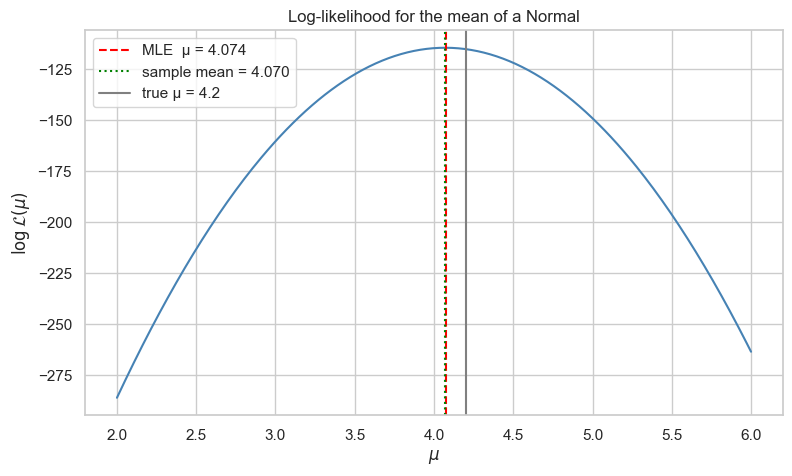

MLE ≈ sample mean: True


In [9]:
# Simulate data from N(true_mu, 1)
true_mu = 4.2
sample = rng.normal(loc=true_mu, scale=1.0, size=80)

def log_likelihood(mu, data):
    return np.sum(stats.norm.logpdf(data, loc=mu, scale=1.0))

mus = np.linspace(2, 6, 300)
log_liks = [log_likelihood(mu, sample) for mu in mus]
mle_mu = mus[np.argmax(log_liks)]
sample_mean = sample.mean()

plt.figure(figsize=(9, 5))
plt.plot(mus, log_liks, color="steelblue")
plt.axvline(mle_mu,     color="red",   ls="--",
            label=f"MLE  \u03bc = {mle_mu:.3f}")
plt.axvline(sample_mean, color="green", ls=":",
            label=f"sample mean = {sample_mean:.3f}")
plt.axvline(true_mu,     color="gray", ls="-",
            label=f"true \u03bc = {true_mu}")
plt.xlabel(r"$\mu$"); plt.ylabel(r"$\log\mathcal{L}(\mu)$")
plt.title("Log-likelihood for the mean of a Normal")
plt.legend()
plt.show()

print(f"MLE \u2248 sample mean: {abs(mle_mu - sample_mean) < 0.02}")

### 6.2 Linear regression as MLE

For linear regression we *assume*

$$y_i \;=\; \mathbf{x}_i^\top \boldsymbol\beta \;+\; \varepsilon_i,
\qquad \varepsilon_i \stackrel{\text{iid}}{\sim} \mathcal{N}(0, \sigma^2).$$

This is a **probabilistic statement**: $y_i$ is a Normal random variable
centered at $\mathbf{x}_i^\top \boldsymbol\beta$. The log-likelihood is

$$\log \mathcal{L}(\boldsymbol\beta, \sigma^2) \;=\; -\frac{n}{2}\log(2\pi\sigma^2) \;-\; \frac{1}{2\sigma^2}\sum_{i=1}^n (y_i - \mathbf{x}_i^\top \boldsymbol\beta)^2.$$

Notice what happens when we try to maximize this over $\boldsymbol\beta$:
the only $\boldsymbol\beta$-dependent piece is $-\tfrac{1}{2\sigma^2}\,\text{SSE}$.
Maximizing that is the **same** as minimizing SSE — which is exactly OLS.

> **Conclusion:** for linear regression under Gaussian noise,
> **MLE = OLS = Gradient Descent to convergence**. The three lenses all
> meet at the same point.

Let's verify this numerically by handing a **generic MLE optimizer** the
log-likelihood and comparing with the closed-form OLS solution.

In [10]:
# Re-use the clean synthetic data from Section 4
n2 = 200
x2 = rng.uniform(-2, 2, n2)
y2 = 2 + 3 * x2 + rng.normal(scale=1.0, size=n2)
X2 = np.column_stack([np.ones(n2), x2])

def neg_log_likelihood(params, X, y):
    beta0, beta1, log_sigma = params
    sigma = np.exp(log_sigma)        # exponentiate to keep sigma > 0
    mu = beta0 + beta1 * X[:, 1]
    return -np.sum(stats.norm.logpdf(y, loc=mu, scale=sigma))

result = optimize.minimize(
    neg_log_likelihood,
    x0=[0.0, 0.0, 0.0],
    args=(X2, y2),
    method="BFGS",
)
beta0_mle, beta1_mle, log_sigma_mle = result.x
sigma_mle = np.exp(log_sigma_mle)

beta_ols_clean = np.linalg.inv(X2.T @ X2) @ X2.T @ y2

print(f"OLS closed-form  : {beta_ols_clean.round(4).tolist()}")
print(f"MLE (numerical)  : [{beta0_mle:.4f}, {beta1_mle:.4f}]")
print(f"MLE \u03c3\u0302         : {sigma_mle:.4f}  "
      f"(true \u03c3 = 1.0)")

OLS closed-form  : [2.1009, 3.0099]
MLE (numerical)  : [2.1009, 3.0099]
MLE σ̂         : 1.0247  (true σ = 1.0)


The MLE estimate agrees with OLS to three decimal places. The extra
parameter $\hat\sigma$ is a bonus — MLE also hands us an estimate of the
noise scale, which we need for confidence intervals and likelihood-ratio
tests.

**Why care about MLE if it just gives OLS?** Because when you change the
noise distribution, the answer changes:

- **Gaussian** noise → MLE = minimize SSE = linear regression.
- **Laplace** noise (heavy tails) → MLE = minimize sum of absolute
  errors = robust/quantile regression.
- **Bernoulli** outcome → MLE = logistic regression.
- **Poisson** outcome → MLE = Poisson regression.

MLE is the general recipe; OLS is the vanilla flavor.

## 7. Regression Metrics — How Good is "Good"?

Once a model is fitted, we need numbers to answer *"how well does it
predict?"*. No single metric is right for every problem — each one
emphasizes a different kind of error.

| Metric | Formula | What it tells you |
|---|---|---|
| **MAE** (Mean Absolute Error) | $\frac{1}{n}\sum \lvert y_i - \hat y_i\rvert$ | Average size of errors, same units as $y$, **robust to outliers** |
| **MSE** (Mean Squared Error) | $\frac{1}{n}\sum (y_i - \hat y_i)^2$ | Penalizes big errors quadratically, units are $y^2$ |
| **RMSE** (Root MSE) | $\sqrt{\text{MSE}}$ | Same emphasis as MSE but back in original units |
| **$R^2$** | $1 - \dfrac{\text{SSE}}{\text{SST}}$ | Fraction of variance explained, dimensionless, can be negative for bad models |
| **Adjusted $R^2$** | $1 - (1-R^2)\dfrac{n-1}{n-p-1}$ | Penalizes adding useless predictors, use when comparing models with different $p$ |
| **MAPE** (Mean Absolute % Error) | $\frac{100}{n}\sum \lvert\tfrac{y_i - \hat y_i}{y_i}\rvert$ | Error as a percentage — great for communicating, breaks when $y_i = 0$ |

### 7.1 Computing all of them on the Advertising data

Let's fit three models of increasing complexity and compare.

In [11]:
# Load the Advertising dataset (same source as the Linear Regression notebook)
try:
    data = pd.read_csv("../datasets/Advertising.csv", index_col=0)
except FileNotFoundError:
    data = pd.read_csv("https://www.statlearning.com/s/Advertising.csv",
                       index_col=0)

X_full = data[["TV", "radio", "newspaper"]]
y_full = data["sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.3, random_state=0
)

models = {
    "TV only":         LinearRegression().fit(X_train[["TV"]], y_train),
    "TV + radio":      LinearRegression().fit(X_train[["TV", "radio"]], y_train),
    "TV+radio+news":   LinearRegression().fit(X_train, y_train),
}

def evaluate(name, model, X_te, y_te):
    y_pred = model.predict(X_te)
    n = len(y_te)
    p = X_te.shape[1]
    mse = mean_squared_error(y_te, y_pred)
    r2  = r2_score(y_te, y_pred)
    return {
        "model": name,
        "p": p,
        "MAE":   mean_absolute_error(y_te, y_pred),
        "MSE":   mse,
        "RMSE":  np.sqrt(mse),
        "R\u00b2":    r2,
        "Adj R\u00b2": 1 - (1 - r2) * (n - 1) / (n - p - 1),
        "MAPE":  mean_absolute_percentage_error(y_te, y_pred),
    }

results = pd.DataFrame([
    evaluate("TV only",       models["TV only"],       X_test[["TV"]],       y_test),
    evaluate("TV + radio",    models["TV + radio"],    X_test[["TV", "radio"]], y_test),
    evaluate("TV+radio+news", models["TV+radio+news"], X_test,               y_test),
]).set_index("model").round(4)
results

,p,MAE,MSE,RMSE,R²,Adj R²,MAPE
model,,,,,,,
TV only,1,2.0575,7.4975,2.7382,0.7256,0.7209,0.2152
TV + radio,2,1.2255,3.6708,1.9159,0.8657,0.8609,0.2026
TV+radio+news,3,1.2334,3.6914,1.9213,0.8649,0.8577,0.2033


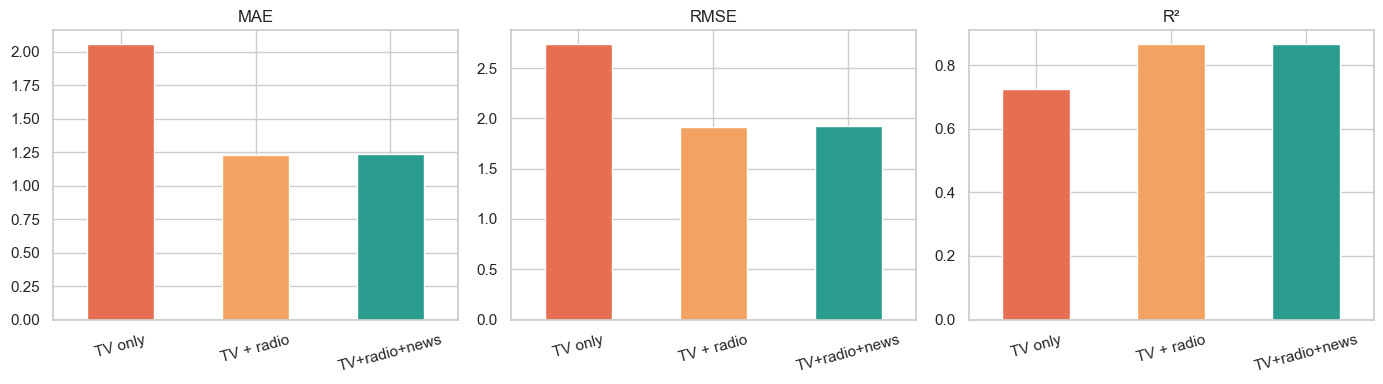

In [12]:
# Visualize the metrics side by side
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["MAE", "RMSE", "R\u00b2"]):
    results[col].plot.bar(ax=ax, color=["#e76f51", "#f4a261", "#2a9d8f"])
    ax.set_title(col)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

### 7.2 Which metric should I use?

| Situation | Preferred metric | Why |
|---|---|---|
| Outliers matter a lot | **MAE** | Quadratic penalties let a single outlier dominate MSE/RMSE |
| Big errors are much worse than small ones | **MSE / RMSE** | Squared penalty punishes large deviations |
| Reporting to non-technical stakeholders | **MAPE** | "13% error" is immediately interpretable |
| Comparing models with different $p$ | **Adjusted $R^2$** | Penalizes useless extra features |
| You want units that match $y$ | **MAE or RMSE** | Both live in the same units as the target |
| You care about *relative* explanatory power | **$R^2$** | Unitless fraction, 0–1 scale |

**Warning about MAPE.** If any true $y_i$ is zero or near-zero, MAPE
explodes. Use it only when $y$ is strictly positive and bounded away
from zero.

## 8. Regularization — Taming Overfitting and Multicollinearity

Linear regression with many features has two chronic illnesses:

1. **Overfitting** — the model memorizes the training noise and
   generalizes poorly.
2. **Coefficient instability** — correlated predictors cause huge,
   compensating swings in the fitted $\hat\beta$ (we saw this already in
   Section 3).

**Regularization** is a single, elegant cure for both. The idea:
**add a penalty on the size of the coefficients** to the loss function.
The optimizer now faces a trade-off — fit the data well *and* keep
coefficients small — which produces smoother, more stable models.

| Method | Penalty | Behavior |
|---|---|---|
| **Ridge** (L2) | $\alpha \sum_j \beta_j^2$ | Shrinks all coefficients toward zero smoothly. Never zeros anything out. |
| **Lasso** (L1) | $\alpha \sum_j \lvert\beta_j\rvert$ | Shrinks and sets some coefficients **exactly to zero** — gives automatic feature selection. |
| **Elastic Net** | mixture of L1 and L2 | Best of both — selection *and* stability when features are correlated. |

$\alpha \ge 0$ is the **regularization strength**. $\alpha = 0$ recovers
plain OLS; $\alpha \to \infty$ forces every coefficient to zero.

### 8.1 Why regularize — an overfitting demonstration

We'll generate 30 samples from a smooth underlying function
$y = \sin(1.5\pi x)$ with small noise, then try to fit a **degree-15
polynomial** by plain OLS. A high-degree polynomial has enough capacity
to memorize every wiggle — and that's exactly the problem.

/Users/aayush/micromamba/envs/stats/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/aayush/micromamba/envs/stats/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/aayush/micromamba/envs/stats/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/aayush/micromamba/envs/stats/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/aayush/micromamba/envs/stats/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/aayush/micromamba/envs/stats/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in ma

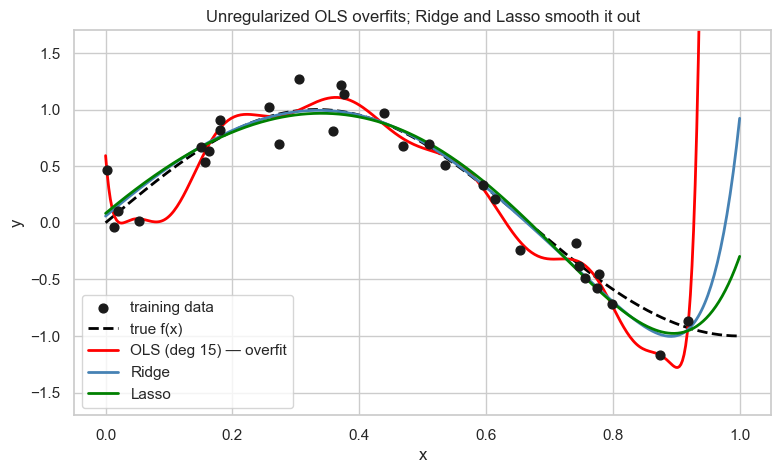

In [13]:
# Underlying truth: y = sin(1.5*pi*x)
def true_f(x):
    return np.sin(1.5 * np.pi * x)

n_sam = 30
x_train = np.sort(rng.uniform(0, 1, n_sam))
y_train = true_f(x_train) + rng.normal(scale=0.15, size=n_sam)
x_grid  = np.linspace(0, 1, 400)

degree = 15
pipe_ols   = make_pipeline(PolynomialFeatures(degree), StandardScaler(),
                           LinearRegression())
pipe_ridge = make_pipeline(PolynomialFeatures(degree), StandardScaler(),
                           Ridge(alpha=0.01))
pipe_lasso = make_pipeline(PolynomialFeatures(degree), StandardScaler(),
                           Lasso(alpha=0.001, max_iter=20000))

pipe_ols.fit(x_train.reshape(-1, 1),   y_train)
pipe_ridge.fit(x_train.reshape(-1, 1), y_train)
pipe_lasso.fit(x_train.reshape(-1, 1), y_train)

plt.figure(figsize=(9, 5))
plt.scatter(x_train, y_train, s=40, color="k", label="training data", zorder=3)
plt.plot(x_grid, true_f(x_grid),                    color="black", lw=2, ls="--", label="true f(x)")
plt.plot(x_grid, pipe_ols.predict(x_grid.reshape(-1,1)),   color="red",     lw=2, label="OLS (deg 15) — overfit")
plt.plot(x_grid, pipe_ridge.predict(x_grid.reshape(-1,1)), color="steelblue", lw=2, label="Ridge")
plt.plot(x_grid, pipe_lasso.predict(x_grid.reshape(-1,1)), color="green",   lw=2, label="Lasso")
plt.ylim(-1.7, 1.7)
plt.xlabel("x"); plt.ylabel("y")
plt.title("Unregularized OLS overfits; Ridge and Lasso smooth it out")
plt.legend()
plt.show()

Plain OLS contorts itself to pass through every noisy point — outside
the training range it spirals off into nonsense. Ridge and Lasso give
far smoother curves that actually track the true $\sin$ function. Let's
quantify the difference:

In [14]:
# Generate a held-out test set drawn from the same truth
x_test = np.sort(rng.uniform(0, 1, 200))
y_test = true_f(x_test) + rng.normal(scale=0.15, size=x_test.size)

for name, model in [("OLS   ", pipe_ols),
                    ("Ridge ", pipe_ridge),
                    ("Lasso ", pipe_lasso)]:
    y_hat = model.predict(x_test.reshape(-1, 1))
    mse = mean_squared_error(y_test, y_hat)
    print(f"{name} test MSE: {mse:.4f}")

OLS    test MSE: 709.1673
Ridge  test MSE: 0.1228
Lasso  test MSE: 0.0409


/Users/aayush/micromamba/envs/stats/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/aayush/micromamba/envs/stats/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/aayush/micromamba/envs/stats/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/aayush/micromamba/envs/stats/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/aayush/micromamba/envs/stats/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/aayush/micromamba/envs/stats/lib/python3.10/site-package

### 8.2 Ridge regression — L2 penalty

Ridge minimizes

$$L_{\text{ridge}}(\boldsymbol\beta) \;=\; \underbrace{\sum_{i=1}^n (y_i - \mathbf{x}_i^\top \boldsymbol\beta)^2}_{\text{OLS loss}} \;+\; \alpha \sum_{j=1}^p \beta_j^2.$$

Closed-form solution:
$\hat{\boldsymbol\beta}_{\text{ridge}} = (X^\top X + \alpha I)^{-1} X^\top y$.
The $+\alpha I$ term **guarantees invertibility** even when $X^\top X$
is singular — Ridge literally solves the OLS fragility problem.

Let's visualize the **regularization path**: how each coefficient
changes as $\alpha$ sweeps from tiny to huge.

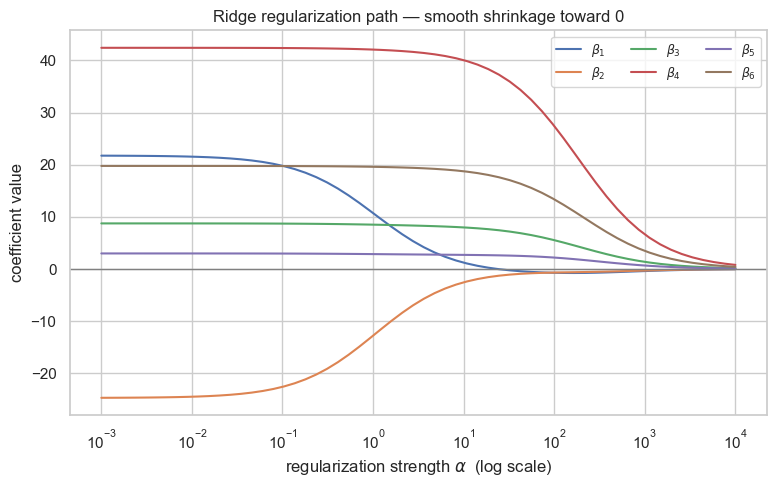

In [15]:
# Build a moderately-correlated design matrix with 6 features
from sklearn.datasets import make_regression
X_reg, y_reg = make_regression(
    n_samples=200, n_features=6, n_informative=4,
    noise=8.0, random_state=0,
)
# Introduce correlation between two features
X_reg[:, 1] = X_reg[:, 0] * 0.9 + rng.normal(scale=0.1, size=200)

alphas = np.logspace(-3, 4, 60)
ridge_path = np.array([
    Ridge(alpha=a).fit(X_reg, y_reg).coef_ for a in alphas
])

plt.figure(figsize=(9, 5))
for j in range(ridge_path.shape[1]):
    plt.plot(alphas, ridge_path[:, j], label=f"$\\beta_{j+1}$")
plt.xscale("log")
plt.xlabel(r"regularization strength $\alpha$  (log scale)")
plt.ylabel("coefficient value")
plt.title("Ridge regularization path — smooth shrinkage toward 0")
plt.axhline(0, color="gray", lw=1)
plt.legend(ncol=3, fontsize=9)
plt.show()

As $\alpha$ grows, every Ridge coefficient smoothly approaches zero
— but **none of them is ever exactly zero**. Ridge shrinks; it does not
select.

### 8.3 Lasso regression — L1 penalty

Lasso replaces the squared penalty with an absolute-value penalty:

$$L_{\text{lasso}}(\boldsymbol\beta) \;=\; \sum_{i=1}^n (y_i - \mathbf{x}_i^\top \boldsymbol\beta)^2 \;+\; \alpha \sum_{j=1}^p \lvert\beta_j\rvert.$$

There is **no closed form** (the penalty is not differentiable at zero),
but specialized solvers like **coordinate descent** are fast. The
important behavioral difference: Lasso can set coefficients **exactly to
zero**, which is why it's used for automatic feature selection.

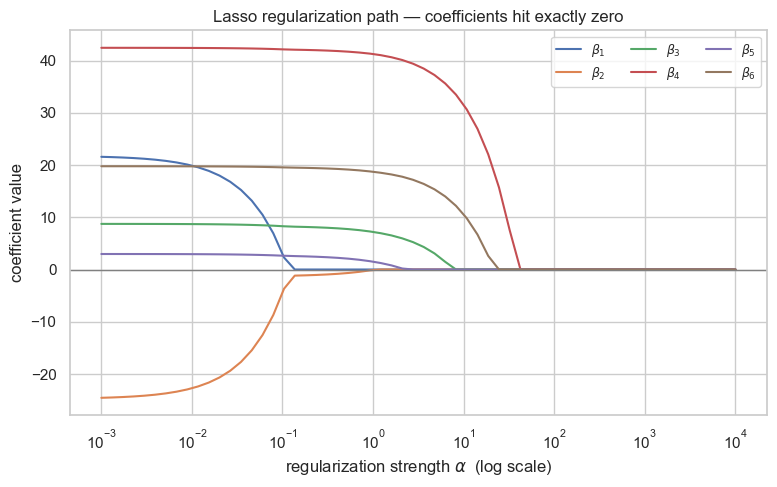

In [16]:
lasso_path = np.array([
    Lasso(alpha=a, max_iter=20000).fit(X_reg, y_reg).coef_ for a in alphas
])

plt.figure(figsize=(9, 5))
for j in range(lasso_path.shape[1]):
    plt.plot(alphas, lasso_path[:, j], label=f"$\\beta_{j+1}$")
plt.xscale("log")
plt.xlabel(r"regularization strength $\alpha$  (log scale)")
plt.ylabel("coefficient value")
plt.title("Lasso regularization path — coefficients hit exactly zero")
plt.axhline(0, color="gray", lw=1)
plt.legend(ncol=3, fontsize=9)
plt.show()

Compare the two paths: Lasso coefficients snap to zero one by one as
$\alpha$ grows, while Ridge coefficients stay away from zero but shrink
together. At a large enough $\alpha$ Lasso keeps only the "most
important" features — that's the feature-selection property.

### 8.4 The geometric intuition — why L1 zeros things out

Here's the classic visualization (from ISLR). Fix two coefficients
$\beta_1, \beta_2$ and draw:

- **Ellipses** — contours of the OLS loss, centered at the OLS solution.
- **Blue region** — the **L2 constraint** $\beta_1^2 + \beta_2^2 \le t$
  (a circle).
- **Red region** — the **L1 constraint**
  $\lvert\beta_1\rvert + \lvert\beta_2\rvert \le t$ (a diamond).

The constrained solution is where the smallest-possible loss ellipse
**just touches** the constraint region. A **diamond has corners** lying
on the axes — so the contact point tends to lie on an axis, meaning one
coordinate is exactly zero. A **circle has no corners**, so the contact
is almost never exactly on an axis.

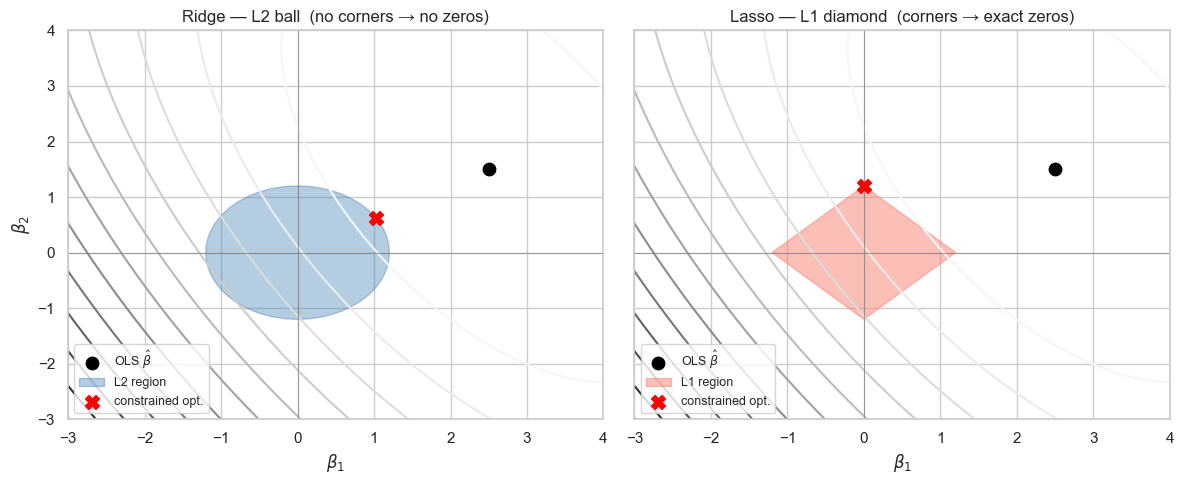

In [17]:
# OLS solution for a toy 2-parameter problem
beta_star = np.array([2.5, 1.5])

# Build an elliptical loss surface centered on beta_star
grid = np.linspace(-3, 4, 400)
B1, B2 = np.meshgrid(grid, grid)
Q = np.array([[2.0, 0.8], [0.8, 1.0]])          # positive-definite Hessian
delta = np.stack([B1 - beta_star[0], B2 - beta_star[1]])
L = 0.5 * np.einsum("ij...,ik...->jk...", delta, delta)   # unused; just for shape
# Recompute properly
L = 0.5 * (Q[0, 0] * (B1 - beta_star[0]) ** 2 +
           2 * Q[0, 1] * (B1 - beta_star[0]) * (B2 - beta_star[1]) +
           Q[1, 1] * (B2 - beta_star[1]) ** 2)

# Constraint radii (chosen to make a nice picture)
t = 1.2

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, shape in zip(axes, ["ridge", "lasso"]):
    cs = ax.contour(B1, B2, L, levels=12, cmap="Greys")
    ax.scatter(*beta_star, color="black", s=80, zorder=5,
               label=r"OLS $\hat\beta$")
    if shape == "ridge":
        theta = np.linspace(0, 2 * np.pi, 200)
        ax.fill(t * np.cos(theta), t * np.sin(theta),
                color="steelblue", alpha=0.4, label="L2 region")
        # Constrained solution: gradient-descent-like projection
        b = beta_star * t / np.linalg.norm(beta_star)
        ax.set_title("Ridge — L2 ball  (no corners → no zeros)")
    else:
        diamond = np.array([[t, 0], [0, t], [-t, 0], [0, -t], [t, 0]])
        ax.fill(diamond[:, 0], diamond[:, 1],
                color="salmon", alpha=0.5, label="L1 region")
        # Constrained solution lands on the top corner because beta_star is
        # above the x-axis — illustrative only
        b = np.array([0.0, t])
        ax.set_title("Lasso — L1 diamond  (corners → exact zeros)")
    ax.scatter(*b, color="red", s=100, zorder=5,
               marker="X", label="constrained opt.")
    ax.axhline(0, color="gray", lw=0.5)
    ax.axvline(0, color="gray", lw=0.5)
    ax.set_xlabel(r"$\beta_1$")
    ax.legend(loc="lower left", fontsize=9)

axes[0].set_ylabel(r"$\beta_2$")
plt.tight_layout()
plt.show()

### 8.5 Elastic Net — the best of both

**Elastic Net** combines the two penalties:

$$L_{\text{EN}} \;=\; \text{SSE} \;+\; \alpha\!\left(\rho \sum_j \lvert\beta_j\rvert \;+\; \tfrac{1-\rho}{2} \sum_j \beta_j^2\right)$$

with $\rho \in [0,1]$ controlling the mix. Elastic Net is the right
choice when you have **groups of correlated features** — Lasso alone
would pick one arbitrarily and drop the rest, while Elastic Net tends to
keep the whole group with shrunk coefficients.

In [18]:
# Quick head-to-head on the same synthetic dataset
alpha = 1.0
fit_ols   = LinearRegression().fit(X_reg, y_reg)
fit_ridge = Ridge(alpha=alpha).fit(X_reg, y_reg)
fit_lasso = Lasso(alpha=alpha, max_iter=20000).fit(X_reg, y_reg)
fit_enet  = ElasticNet(alpha=alpha, l1_ratio=0.5, max_iter=20000).fit(X_reg, y_reg)

comp = pd.DataFrame({
    "OLS":         fit_ols.coef_,
    "Ridge":       fit_ridge.coef_,
    "Lasso":       fit_lasso.coef_,
    "Elastic Net": fit_enet.coef_,
}, index=[f"feat {i+1}" for i in range(X_reg.shape[1])]).round(3)
comp

,OLS,Ridge,Lasso,Elastic Net
feat 1,21.757,10.711,-0.000,-0.566
feat 2,-24.757,-12.802,-0.068,-0.428
feat 3,8.736,8.495,7.191,5.152
feat 4,42.435,42.094,41.243,27.100
feat 5,2.972,2.844,1.496,1.797
feat 6,19.768,19.597,18.702,13.035


### 8.6 Choosing $\alpha$ — cross-validation

$\alpha$ is a hyperparameter — not learned from the training data
directly. The standard recipe is **k-fold cross-validation**: for each
candidate $\alpha$, train on $k-1$ folds and score on the held-out fold;
pick the $\alpha$ with the best average score.

`sklearn` ships convenience classes `RidgeCV` / `LassoCV` that do this
automatically.

In [19]:
alphas_cv = np.logspace(-3, 3, 80)

ridge_cv = RidgeCV(alphas=alphas_cv, cv=5).fit(X_reg, y_reg)
lasso_cv = LassoCV(alphas=alphas_cv, cv=5, max_iter=20000).fit(X_reg, y_reg)

print(f"Ridge CV  best alpha : {ridge_cv.alpha_:.4f}")
print(f"Lasso CV  best alpha : {lasso_cv.alpha_:.4f}")
print(f"Ridge CV  R\u00b2        : {ridge_cv.score(X_reg, y_reg):.4f}")
print(f"Lasso CV  R\u00b2        : {lasso_cv.score(X_reg, y_reg):.4f}")

Ridge CV  best alpha : 0.7693
Lasso CV  best alpha : 0.9163
Ridge CV  R²        : 0.6360
Lasso CV  R²        : 0.6333


/Users/aayush/micromamba/envs/stats/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/aayush/micromamba/envs/stats/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/aayush/micromamba/envs/stats/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/aayush/micromamba/envs/stats/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/aayush/micromamba/envs/stats/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/aayush/micromamba/envs/stats/lib/python3.10/site-package

## 9. Key Takeaways

1. **Fitting is optimization.** All three paradigms — OLS, Gradient
   Descent, MLE — are solving the same optimization problem through
   different doors.
2. **Gradient Descent trades one expensive exact step for many cheap
   approximate steps.** This is how you scale to huge datasets, streaming
   data, and non-OLS losses.
3. **The learning rate is the single most important GD hyperparameter.**
   Too small = slow; too large = diverge. Always monitor the loss curve.
4. **MLE = OLS under Gaussian noise**, but MLE is the general recipe —
   change the noise distribution and you get logistic regression,
   Poisson regression, and the rest of the GLM family.
5. **No single regression metric rules.** Pick MAE for outlier
   robustness, RMSE to punish big misses, Adjusted $R^2$ when comparing
   models of different sizes, MAPE for stakeholder-friendly reports.
6. **Regularization is non-negotiable for high-dimensional data.**
   Ridge smooths and stabilizes; Lasso does feature selection; Elastic
   Net does both. Always cross-validate $\alpha$.

## 10. Practice Exercises

1. **Learning-rate hunt.** For the synthetic linear data in Section 4,
   sweep $\eta \in \{10^{-4}, 10^{-3}, \ldots, 1\}$ and record the
   iteration at which the loss first drops below $0.1$. Plot
   "iterations to convergence" vs $\eta$ on a log-log axis.
2. **SGD vs batch.** Run batch GD and SGD from the same starting point
   on the same data, record the loss after each *epoch* (full pass),
   and plot them on the same axes. Which converges faster in wall-clock
   terms? In number of iterations?
3. **Huber loss with GD.** Implement gradient descent for **Huber
   regression** (quadratic for small residuals, linear for large ones).
   Compare its behavior with OLS when you inject five large outliers
   into the Advertising data.
4. **MLE for Poisson regression.** Generate counts
   $y_i \sim \text{Poisson}(\exp(\beta_0 + \beta_1 x_i))$ and use
   `scipy.optimize.minimize` to recover $\beta_0, \beta_1$ by maximizing
   the Poisson log-likelihood. Compare with `statsmodels.GLM(..., family=sm.families.Poisson())`.
5. **Outlier sensitivity of metrics.** Take the Advertising test set and
   add a single huge outlier ($y = 200$). Recompute MAE, RMSE, $R^2$,
   and MAPE. Which metric moves the most? Which is most stable?
6. **Regularization path on Advertising.** Build polynomial features
   (degree 3) of the Advertising predictors, then plot Ridge and Lasso
   regularization paths side by side. Does Lasso drop any features
   entirely?
7. **Ridge vs Lasso via CV.** Use `RidgeCV` and `LassoCV` on a
   **standardized** Advertising dataset. Report the best $\alpha$ and
   the test-set RMSE for each, and note which features (if any) Lasso
   zeros out.
8. **From-scratch Ridge.** Implement Ridge regression yourself using
   $\hat\beta = (X^\top X + \alpha I)^{-1} X^\top y$ and verify against
   `sklearn.linear_model.Ridge` for a handful of $\alpha$ values.